### Cluster-Based Dataset Augmentation Pipeline

This notebook performs a full pipeline to assign **cluster-level semantic task IDs** to each prompt in both the training and test sets of the GPT-3 Arena dataset. These cluster labels are generated based on topic embeddings and serve as additional structured features for downstream modeling or analysis.

**What this notebook does:**

1. **Preprocessing**: Topic modeling fields (`topic_modeling_1/2/3`) are flattened from lists into comma-separated strings to unify input formatting.
2. **Topic Embedding**: All unique topics are embedded using the `all-MiniLM-L6-v2` SentenceTransformer model to capture semantic similarity.
3. **Dimensionality Reduction**: UMAP is used to project the 384-dimensional embeddings into a 5D space suitable for clustering.
4. **Clustering**: K-Means (`K=30`) clusters the reduced embeddings. Small, underpopulated clusters are merged into their nearest major cluster based on centroid distance.
5. **Cluster Assignment**: Each prompt is assigned a cluster ID by mapping its associated topic(s) to the precomputed cluster dictionary. If a topic is not seen during training, it is dynamically embedded and mapped to its nearest cluster.
6. **Dataset Augmentation**: Cluster IDs are added as new columns to the training and test datasets, creating enriched datasets with semantic task labels.

This enriched data can be used for cluster-aware model training, performance evaluation, or interpretability analysis in the context of LLM-based chatbot comparisons.


In [3]:
import pandas as pd
import numpy as np
import re
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestCentroid
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import calinski_harabasz_score, silhouette_score
import matplotlib.pyplot as plt

# Load GPT-3 generated topic modeling data
gpt3_scores_df = pd.read_json(
    "_shared/data100-readonly/fa24_grad_project_data/nlp-chatbot-analysis_data/training-set/chatbot-arena-gpt3-scores.jsonl.gz", 
    lines=True,
    compression="gzip"
)

# Helper function to flatten list-type columns into comma-separated strings
def flatten_list_columns(df, columns):
    for col in columns:
        df[col] = df[col].apply(lambda x: x if isinstance(x, list) else [x] if pd.notnull(x) else [])
        df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if x else None)
    return df

# Apply the flattening process to topic columns
gpt3_scores_df = flatten_list_columns(
    gpt3_scores_df, 
    ["topic_modeling_1", "topic_modeling_2", "topic_modeling_3"]
)

# Gather all unique topic strings
all_topics = pd.concat([
    gpt3_scores_df["topic_modeling_1"],
    gpt3_scores_df["topic_modeling_2"],
    gpt3_scores_df["topic_modeling_3"]
]).dropna().unique()

# Generate sentence embeddings for topics
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
topic_embeddings = embedding_model.encode(all_topics, show_progress_bar=True)
print(f"Embedding shape: {topic_embeddings.shape}")  # Output (N, 384)

print("\nPerforming UMAP dimensionality reduction...")
umap_model = UMAP(
    n_neighbors=100,
    n_components=5,
    min_dist=0.25,
    metric='cosine',
    random_state=42,
    densmap=False 
)
reduced_embeddings = umap_model.fit_transform(topic_embeddings)

# Normalize the reduced embeddings
scaler = StandardScaler()
reduced_embeddings_scaled = scaler.fit_transform(reduced_embeddings)

# Apply improved K-Means clustering
kmeans = KMeans(
    n_clusters=30,
    init='k-means++',
    n_init=50,
    max_iter=1000,
    tol=1e-6,
    algorithm='elkan',
    random_state=42
)
cluster_labels = kmeans.fit_predict(reduced_embeddings_scaled)

# Semantic keyword rules for labeling
SEMANTIC_RULES = {
    r"\b(code|debug|algorithm|api|git)\b": "programming_code_generation",
    r"\b(optimiz|refactor|complexity)\b": "programming_code_optimization",
    r"\b(cyber|encrypt|vulnerability)\b": "programming_security",
    r"\b(equation|derivative|integral|matrix)\b": "mathematics_calculation",
    r"\b(proof|theorem|axiom|logical)\b": "mathematics_proving",
    r"\b(probability|statistic|distribution)\b": "mathematics_probability",
    r"\b(diagnos|symptom|pathology)\b": "medical_diagnosis",
    r"\b(drug|pharmaco|dosage)\b": "medical_pharmacy",
    r"\b(genetic|protein|dna)\b": "medical_genomics",
    r"\b(contract|clause|agreement)\b": "legal_contract",
    r"\b(patent|copyright|intellectual)\b": "legal_ip",
    r"\b(compli|regulation|gdpr)\b": "legal_compliance",
    r"\b(teach|curriculum|pedagogy)\b": "education_instruction",
    r"\b(exam|quiz|assessment)\b": "education_evaluation",
    r"\b(translate|grammar|vocabulary)\b": "language_translation",
    r"\b(stock|portfolio|dividend)\b": "finance_investment",
    r"\b(loan|mortgage|interest)\b": "finance_banking",
    r"\b(tax|audit|compliance)\b": "finance_accounting",
    r"\b(image|vision|detection)\b": "multimodal_vision",
    r"\b(audio|speech|transcribe)\b": "multimodal_audio",
    r"\b(video|frame|streaming)\b": "multimodal_video"
}

# Function to generate hierarchical domain-subdomain labels
def enhanced_label_generation(topics_list):
    combined_text = " ".join(topics_list).lower()
    domain_hierarchy = {
        "programming": ["code_generation", "code_optimization", "security"],
        "mathematics": ["calculation", "proving", "probability"],
        "medical": ["diagnosis", "pharmacy", "genomics"],
        "legal": ["contract", "ip", "compliance"],
        "education": ["instruction", "evaluation", "translation"],
        "finance": ["investment", "banking", "accounting"],
        "multimodal": ["vision", "audio", "video"]
    }
    for domain in domain_hierarchy:
        if re.search(r"\b(" + "|".join(domain_hierarchy[domain]) + r")\b", combined_text):
            sub_pattern = "|".join([f"({s})" for s in domain_hierarchy[domain]])
            sub_match = re.search(sub_pattern, combined_text)
            sub_label = sub_match.group() if sub_match else "general"
            return f"{domain}_{sub_label}"
    tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=100)
    try:
        tfidf_matrix = tfidf.fit_transform(topics_list)
        feature_names = tfidf.get_feature_names_out()
        top_words = [
            word for word, _ in 
            sorted(zip(feature_names, np.asarray(tfidf_matrix.sum(axis=0).flatten())),
                   key=lambda x: -x[1])
            if len(word) > 4
        ][:5]
        return "_".join(top_words)
    except:
        return "cross_domain"

# Merge small clusters into nearest large clusters
print("\nMerging small clusters...")
def merge_small_clusters(embeddings, labels, min_size_ratio=0.01):
    min_size = int(len(labels) * min_size_ratio)
    unique_labels, counts = np.unique(labels, return_counts=True)
    large_labels = unique_labels[counts >= min_size]
    small_labels = unique_labels[counts < min_size]
    if len(large_labels) == 0:
        return labels
    clf = NearestCentroid().fit(embeddings, labels)
    label_map = {}
    for sl in small_labels:
        centroid = clf.centroids_[sl].reshape(1, -1)
        nearest_label = clf.predict(centroid)[0]
        label_map[sl] = nearest_label if nearest_label in large_labels else large_labels[0]
    return np.vectorize(lambda x: label_map.get(x, x))(labels)

processed_labels = merge_small_clusters(
    embeddings=reduced_embeddings_scaled,  
    labels=cluster_labels
)

# Create mapping from topic text to cluster ID
topic_to_cluster = {}
for topic_idx, label in enumerate(processed_labels):
    real_topic = all_topics[topic_idx]
    topic_to_cluster[real_topic] = label

print(f"Cluster mapping complete: {len(topic_to_cluster)} topics assigned to cluster IDs.")

def map_topics_to_clusters(topics_str):
    if not topics_str or pd.isnull(topics_str):
        return "0"
    clean_topic = topics_str.replace(",", " ").strip()
    if clean_topic in topic_to_cluster:
        cid = topic_to_cluster[clean_topic]
    else:
        emb = embedding_model.encode([clean_topic])       # (1, emb_dim)
        emb_umap = umap_model.transform(emb)              # (1, 5)
        emb_scaled = scaler.transform(emb_umap)           # (1, 5)
        cid = kmeans.predict(emb_scaled)[0]
        topic_to_cluster[clean_topic] = cid

    return str(cid)
gpt3_scores_df["topic_modeling_1_cluster"] = gpt3_scores_df["topic_modeling_1"].apply(map_topics_to_clusters)
gpt3_scores_df["topic_modeling_2_cluster"] = gpt3_scores_df["topic_modeling_2"].apply(map_topics_to_clusters)
gpt3_scores_df["topic_modeling_3_cluster"] = gpt3_scores_df["topic_modeling_3"].apply(map_topics_to_clusters)

Batches:   0%|          | 0/681 [00:00<?, ?it/s]

Embedding shape: (21767, 384)

Performing UMAP dimensionality reduction...


/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



Merging small clusters...
Cluster mapping complete: 21767 topics assigned to cluster IDs.


/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: F

In [4]:
gpt3_scores_df.head(5)

,question_id,prompt,openai_scores_raw_choices_nested,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster
0,58210e39b3fd4441a2bd4a518bb44c2d,What is the difference between OpenCL and CUDA?,"[{'finish_reason': 'stop', 'index': 0, 'logpro...",Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,16,0,16
1,2564acd09e3942fd97657d05282d4389,Why did my parent not invite me to their wedding?,"[{'finish_reason': 'stop', 'index': 0, 'logpro...","Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,1,1,1
2,90bfd142157948aba01931726c888e7f,"Fuji vs. Nikon, which is better?","[{'finish_reason': 'stop', 'index': 0, 'logpro...",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,2,16,2
3,a7c5accc53e649a3bc6b2e41d962ebc4,How to build an arena for chatbots?,"[{'finish_reason': 'stop', 'index': 0, 'logpro...",Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,19,19,19
4,adf27e819a3c494cb6e993f0c660e097,When is it today?,"[{'finish_reason': 'stop', 'index': 0, 'logpro...",Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,16,16,16


In [5]:
# 3d Visual Cluster
from sklearn.decomposition import PCA
import plotly.express as px

def plot_umap_clusters(reduced_embeddings, labels, save_path="clusters_umap.html"):
    """
    Interactive 3D Cluster Distribution Plot using Plotly.
    
    Parameters:
    - reduced_embeddings: np.ndarray
        The UMAP-reduced embeddings.
    - labels: array-like
        Cluster labels for each sample.
    - save_path: str
        The file path to save the interactive plot as an HTML file.
    """
    # Use PCA to further reduce to 3 dimensions if necessary
    if reduced_embeddings.shape[1] > 3:
        pca = PCA(n_components=3)
        vis_embeddings = pca.fit_transform(reduced_embeddings)
    else:
        vis_embeddings = reduced_embeddings

    fig = px.scatter_3d(
        x=vis_embeddings[:, 0],
        y=vis_embeddings[:, 1],
        z=vis_embeddings[:, 2],
        color=labels.astype(str),
        labels={'color': 'Cluster ID'},
        title="3D Cluster Distribution (UMAP Reduced)"
    )
    fig.write_html(save_path)
    print(f"✅ 3D clustering plot saved to {save_path}")

plot_umap_clusters(reduced_embeddings_scaled, processed_labels)


✅ 3D clustering plot saved to clusters_umap.html


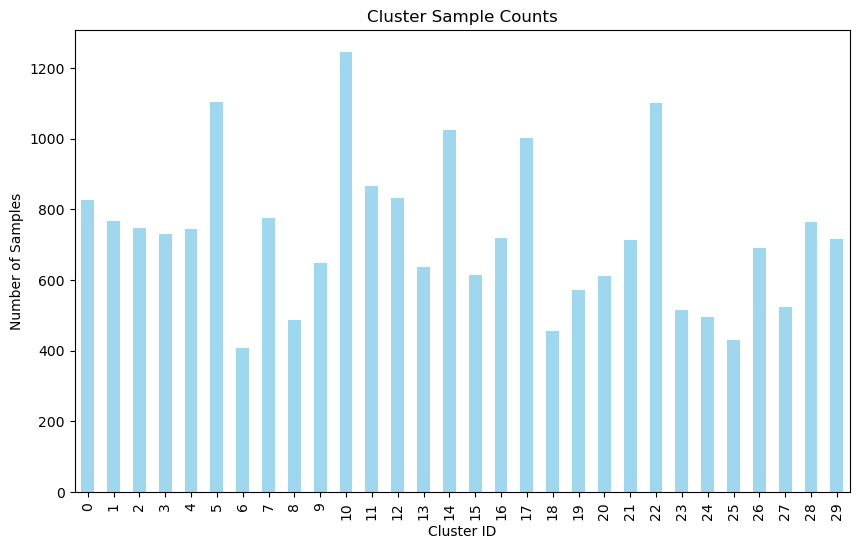

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_cluster_counts(labels):
    label_counts = pd.Series(labels).value_counts().sort_index()
    
    plt.figure(figsize=(10, 6))
    label_counts.plot(kind='bar', color='skyblue', alpha=0.8)
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Samples")
    plt.title("Cluster Sample Counts")
    plt.show()
plot_cluster_counts(processed_labels)


In [7]:
# 2d Visual Cluster
import plotly.express as px

def plot_interactive_2d(embeddings, labels, save_path="clusters_2d.html"):
    if embeddings.shape[1] > 2:
        pca = PCA(n_components=2)
        vis_embeddings = pca.fit_transform(embeddings)
    else:
        vis_embeddings = embeddings
    
    fig = px.scatter(
        x=vis_embeddings[:, 0],
        y=vis_embeddings[:, 1],
        color=labels.astype(str),
        labels={'color': 'Cluster ID'},
        title="2D Cluster Distribution (Interactive)"
    )
    fig.write_html(save_path)
    print(f"✅ 2D clustering plot saved to {save_path}")
    fig.show()

# 示例调用：
plot_interactive_2d(reduced_embeddings_scaled, processed_labels)


✅ 2D clustering plot saved to clusters_2d.html


In [8]:
output_csv = "trained_enhanced_topics_with_clusters.csv"
gpt3_scores_df.to_csv(output_csv, index=False)
print(f"Save in: {output_csv}")

Save in: trained_enhanced_topics_with_clusters.csv


In [9]:
print("\n===== Mapping Cluster IDs for the Test Set =====")

# 1) Load the test set
test_json_path = "_shared/data100-readonly/fa24_grad_project_data/nlp-chatbot-analysis_data/test-set/arena-test-set-topic-modeling.jsonl.gz"
test_df = pd.read_json(test_json_path, lines=True, compression="gzip")

# 2) Flatten list-type columns to comma-separated strings, consistent with training set
def flatten_list_columns(df, columns):
    for col in columns:
        df[col] = df[col].apply(
            lambda x: x if isinstance(x, list) else [x] if pd.notnull(x) else []
        )
        df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if x else None)
    return df

test_df = flatten_list_columns(
    test_df, 
    ["topic_modeling_1", "topic_modeling_2", "topic_modeling_3"]
)

# 3) Apply the same topic-to-cluster mapping function used for the training set
test_df["topic_modeling_1_cluster"] = test_df["topic_modeling_1"].apply(map_topics_to_clusters)
test_df["topic_modeling_2_cluster"] = test_df["topic_modeling_2"].apply(map_topics_to_clusters)
test_df["topic_modeling_3_cluster"] = test_df["topic_modeling_3"].apply(map_topics_to_clusters)


output_csv = "test_enhanced_topics_with_clusters.csv"
test_df.to_csv(output_csv, index=False)
print(f"Save in: {output_csv}")


===== Mapping Cluster IDs for the Test Set =====


/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all

Save in: test_enhanced_topics_with_clusters.csv


/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/haydengu/miniconda3/envs/llm-nlp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all